## Criterion 3 Interventional Precision

Criteria 1 (faithfulness) and 2 (description length) are already computed per-level in the individual notebooks and saved to JSON. This notebook evaluates **Criterion 3: interventional precision** for both tasks.

**The test**: take a *base* input and a *source* input with a different correct answer. Replace only the circuit components' activations on the base run with those from the source run. If the circuit genuinely mediates the computation, the model should now output the *source* answer. Interventional precision = fraction of pairs where this holds.

**Tasks covered:**
- **Grokking** (1-layer model, modular arithmetic mod 113): neuron clusters (L1), Fourier logit directions (L2), SAE features (L3)
- **IOI** (GPT-2 Small, indirect object identification): MLP neurons (L1), attention heads (L2), SAE features at MLP3 (L3)

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
import random
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results")

# Grokking result paths
L1_RESULTS = RESULTS_DIR / "level1/level1_results.json"
L2_RESULTS = RESULTS_DIR / "level2/level2_results.json"
L3_RESULTS = RESULTS_DIR / "level3/level3_results.json"
SAE_PATH   = Path("../data/grokking_sae_l1_2e-1.pt")
MODEL_PATH = Path("../data/grokking_model.pt")

# IOI result paths
L1_IOI_RESULTS = RESULTS_DIR / "level1IOI/level1IOI_results.json"
L2_IOI_RESULTS = RESULTS_DIR / "level2IOI/level2IOI_results.json"
L3_IOI_RESULTS = RESULTS_DIR / "level3IOI/level3IOI_results2.json"
SAE_IOI_PATH   = Path("../data/gpt2_sae_layer9.pt")

OUT_DIR = RESULTS_DIR / "criteria"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Using device: cpu


## Part 1: Grokking task

Rebuild dataset and model

In [2]:
P = 113
EQ_TOKEN = P

all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels = (aa + bb) % P
inputs = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)

N = len(inputs)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs = inputs[idx[n_test:]]
train_labels = labels[idx[n_test:]]
test_inputs= inputs[idx[:n_test]]
test_labels = labels[idx[:n_test]]

cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()

Moving model to device:  cpu


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0): TransformerBlock(
      (ln1): Identity()
      (ln2): Identity()
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hook_resid_pre): HookPoint()
      (hook_resid_mid): HookPoint()
      (hook_resid_post): HookPoint()
    )
  )
  (unembed): Unembed(
    (hook_in): HookPoint()
    (hook_out): 

Rebuild SAE

In [3]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in, d_sae, l1_coeff=2e-2):
        super().__init__()
        self.d_in = d_in
        self.d_sae = d_sae
        self.l1_coeff = l1_coeff
        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))
        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self._normalise_decoder()

    def _normalise_decoder(self):
        with torch.no_grad():
            self.W_dec.data = nn.functional.normalize(self.W_dec.data, dim=1)

    def encode(self, x):
        return torch.relu((x - self.b_dec) @ self.W_enc + self.b_enc)

    def decode(self, f):
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f = self.encode(x)
        x_hat = self.decode(f)
        l2_loss = (x - x_hat).pow(2).sum(dim=-1).mean()
        l1_loss = f.abs().sum(dim=-1).mean()
        loss = l2_loss + self.l1_coeff * l1_loss
        return loss, x_hat, f, l2_loss, l1_loss

D_IN = model.cfg.d_mlp
D_SAE = D_IN * 4

sae = SparseAutoencoder(d_in=D_IN, d_sae=D_SAE).to(device)
sae.load_state_dict(torch.load(SAE_PATH, map_location=device))
sae.eval()

SparseAutoencoder()

Load circuit definitions from saved results

In [4]:
with open(L1_RESULTS) as f: l1 = json.load(f)
with open(L2_RESULTS) as f: l2 = json.load(f)
with open(L3_RESULTS) as f: l3 = json.load(f)

# Level 1: reconstruct neuron list from frequency cluster components
with open(Path("../results/level1/level1_results.json")) as f:
    l1_full = json.load(f)

# Circuit components are cluster names e.g. ["freq_14", "freq_35"]
circuit_l1_clusters = l1_full["circuit_components"]
print(f"Level 1 circuit clusters: {circuit_l1_clusters}")

# Level 2: Fourier logit direction components
circuit_l2 = l2["circuit_components"]
print(f"Level 2 circuit components: {circuit_l2}")

# Level 3: SAE feature indices
circuit_l3 = l3["circuit_features"]
print(f"Level 3 circuit: {len(circuit_l3)} SAE features")

Level 1 circuit clusters: ['freq_14', 'freq_49', 'freq_17', 'noise_cluster']
Level 2 circuit components: ['cos_14', 'sin_14', 'cos_17', 'sin_17']
Level 3 circuit: 158 SAE features


Build the intervention test set

For each test pair we need a base input and a source input with a different answer. We draw 200 such pairs from the test set, ensuring base and source answers differ so the intervention is non-trivial.

In [5]:
N_PAIRS = 200
torch.manual_seed(99)

base_idx = torch.randperm(len(test_inputs))[:N_PAIRS]
source_idx = torch.randperm(len(test_inputs))[:N_PAIRS]

# Make sure base and source have different answers
for i in range(N_PAIRS):
      while test_labels[source_idx[i]] == test_labels[base_idx[i]]:
            source_idx[i] = torch.randint(0, len(test_inputs), (1,)).item()

base_x = test_inputs[base_idx].to(device)    # [N_PAIRS, 3]
base_y = test_labels[base_idx].to(device)    # [N_PAIRS]
source_x = test_inputs[source_idx].to(device)  # [N_PAIRS, 3]
source_y = test_labels[source_idx].to(device)  # [N_PAIRS] these are the targets

print(f"Intervention pairs: {N_PAIRS}")
print(f"Example: base answer={base_y[0].item():3d}  source answer={source_y[0].item():3d}  (should differ)")
print(f"All pairs have different answers: {(base_y != source_y).all().item()}")

Intervention pairs: 200
Example: base answer= 65  source answer= 26  (should differ)
All pairs have different answers: True


Cache activations for source inputs

In [6]:
MLP_HOOK = "blocks.0.mlp.hook_post"

with torch.no_grad():
    _, src_cache = model.run_with_cache(
        source_x, names_filter=MLP_HOOK)

src_mlp = src_cache[MLP_HOOK][:, -1, :]        # [N_PAIRS, D_IN]

with torch.no_grad():
    src_feats = sae.encode(src_mlp)             # [N_PAIRS, D_SAE]

print(f"Source MLP activations:  {src_mlp.shape}")
print(f"Source SAE features: {src_feats.shape}")

Source MLP activations:  torch.Size([200, 512])
Source SAE features: torch.Size([200, 2048])


Define the precision metric

In [7]:
def interventional_precision(patched_logits, source_labels):
    """
    Fraction of interventions where the model predicts the SOURCE answer.
    does patching the circuit make the model behave as if it received the source input?
    """
    predictions = patched_logits.argmax(dim=-1)   # [N_PAIRS]
    return (predictions == source_labels).float().mean().item()

def chance_precision():
    """Baseline: random prediction over P classes."""
    return 1.0 / P

# Also compute unpatched baseline  
with torch.no_grad():
    base_logits = model(base_x)[:, -1, :]
base_pred_source = interventional_precision(base_logits, source_y)
base_pred_base = (base_logits.argmax(-1) == base_y).float().mean().item()

print(f"Unpatched accuracy on base answer: {base_pred_base:.4f}  (should be ~1.0)")
print(f"Unpatched accuracy on source answer: {base_pred_source:.4f}  (should be ~{chance_precision():.4f})")
print(f"Chance level (1/113): {chance_precision():.4f}")

Unpatched accuracy on base answer: 1.0000  (should be ~1.0)
Unpatched accuracy on source answer: 0.0000  (should be ~0.0088)
Chance level (1/113): 0.0088


Level 1 interventional precision

In [8]:
# Level 1: patch at the cluster level using mean ablation
# Rebuild neuron-to-cluster mapping (minimal version, no full FFT needed)
# since we saved cluster names but not neuron indices

# Re-derive neuron cluster membership
import einops

P = 113
HOOK = "blocks.0.mlp.hook_post"

fourier_basis_l1 = [torch.ones(P) / np.sqrt(P)]
for i in range(1, P // 2 + 1):
    cos_v = torch.cos(2 * torch.pi * torch.arange(P) * i / P)
    sin_v = torch.sin(2 * torch.pi * torch.arange(P) * i / P)
    fourier_basis_l1.append(cos_v / cos_v.norm())
    fourier_basis_l1.append(sin_v / sin_v.norm())
fourier_basis_l1 = torch.stack(fourier_basis_l1, dim=0).to(device)

all_inputs_l1 = torch.stack([
    *torch.meshgrid(torch.arange(P), torch.arange(P), indexing='ij')
], dim=-1).reshape(-1, 2)
all_inputs_l1 = torch.cat([
    all_inputs_l1,
    torch.full((P*P, 1), P)], dim=1)

with torch.no_grad():
    _, c = model.run_with_cache(all_inputs_l1.to(device),
                                names_filter=HOOK)
na = c[HOOK][:, -1, :]
na_c = na - na.mean(0, keepdim=True)
na_2d = einops.rearrange(na_c, '(x y) d -> x y d', x=P, y=P)
fa = torch.einsum('xyd,fx,Fy->fFd', na_2d, fourier_basis_l1, fourier_basis_l1)
fa_flat = fa.reshape(P*P, model.cfg.d_mlp)

indices_l1 = np.array([[2*f-1, 2*f, (2*f-1)*P, (2*f)*P,
                        (2*f-1)*P+2*f-1, (2*f-1)*P+2*f,
                        (2*f)*P+2*f-1, (2*f)*P+2*f]
                        for f in range(1, P//2+1)])

nn_var  = fa_flat.pow(2).sum(0)
fv = fa_flat[indices_l1.flatten()].reshape(P//2, 8, model.cfg.d_mlp)
ne = fv.pow(2).sum(1) / nn_var
nf = (ne.argmax(0) + 1).clone()
nf[ne.max(0).values < 0.85] = -1
nf_np = nf.cpu().numpy()

# Build circuit cluster tensor
circuit_l1_t = torch.tensor(
    [i for cname in circuit_l1_clusters
    if cname != "noise_cluster"
    for i in np.where(nf_np == int(cname.split("_")[1]))[0].tolist()],
    dtype=torch.long)

print(f"Circuit L1: {len(circuit_l1_t)} neurons from {circuit_l1_clusters}")

# Compute mean acts from training set for ablation baseline
with torch.no_grad():
    _, mc = model.run_with_cache(train_inputs.to(device), names_filter=HOOK)
mean_acts_l1 = mc[HOOK][:, -1, :].mean(0)

# Cache clean MLP activations for eval set
with torch.no_grad():
    _, src_cache_l1 = model.run_with_cache(source_x, names_filter=MLP_HOOK)
src_mlp_l1 = src_cache_l1[MLP_HOOK][:, -1, :]

def l1_patch_hook(value, hook):
    value[:, -1, :] = mean_acts_l1
    value[:, -1, circuit_l1_t] = src_mlp_l1[:, circuit_l1_t]  # SOURCE, not base
    return value


with torch.no_grad():
    l1_patched_logits = model.run_with_hooks(
        base_x, fwd_hooks=[(HOOK, l1_patch_hook)])[:, -1, :]

precision_l1 = interventional_precision(l1_patched_logits, source_y)
print(f"Level 1 interventional precision: {precision_l1:.4f}")

Circuit L1: 387 neurons from ['freq_14', 'freq_49', 'freq_17', 'noise_cluster']
Level 1 interventional precision: 0.9950


Level 2 interventional precision

For Level 2 Criterion 3, the intervention has to stay in logit space to be consistent. The test becomes: take the base input's logits, remove its key frequency components, inject the source input's key frequency components in their place, and check if the model now predicts the source answer.

In [9]:
# Level 2 interventional precision logit space Fourier patching

# Run model on all eval pairs
with torch.no_grad():
    base_logits_l2 = model(base_x)[:, -1, :]    # [N_PAIRS, P]
    source_logits_l2 = model(source_x)[:, -1, :]  # [N_PAIRS, P]

# For each pair: remove base frequency components, inject source ones
# We need to do this per-example since base and source differ per pair
def patch_logits_l2(base_log, src_log, key_freqs):
    """
    For per-example logits [N, P]: subtract each key frequency component
    from base and add the corresponding component from source.
    Projects along the P output dimension using 1D Fourier basis vectors.
    """
    patched = base_log.clone()

    for k in key_freqs:
        cos_out = torch.cos(2 * torch.pi * k * torch.arange(P).float()/ P).to(base_log.device)
        sin_out = torch.sin(2 * torch.pi * k * torch.arange(P).float()/ P).to(base_log.device)
        cos_out = cos_out / cos_out.norm()
        sin_out = sin_out / sin_out.norm()

        base_cos = (base_log * cos_out).sum(-1, keepdim=True)
        base_sin = (base_log * sin_out).sum(-1, keepdim=True)
        src_cos = (src_log  * cos_out).sum(-1, keepdim=True)
        src_sin = (src_log  * sin_out).sum(-1, keepdim=True)

        patched = patched \
            - base_cos * cos_out \
            - base_sin * sin_out \
            + src_cos  * cos_out \
            + src_sin  * sin_out

    return patched

KEY_FREQS_L2 = l2["key_freqs"]

patched_l2 = patch_logits_l2(base_logits_l2, source_logits_l2, KEY_FREQS_L2)
precision_l2 = interventional_precision(patched_l2, source_y)
print(f"Level 2 interventional precision: {precision_l2:.4f}")

Level 2 interventional precision: 0.6550


## Level 3 interventional precision

Patch the `k_95` circuit SAE features from the source input into the base forward pass,
decode back to MLP activation space via `sae.decode`, inject at `hook_post`, and measure
whether the model predicts the source answer.

The circuit features were selected in `04_level3_sae.ipynb` by ranking all 2048 features on
their individual recovery score. The goal here is to test whether those specific features
**causally mediate** the answer computation 

In [10]:
MLP_HOOK = "blocks.0.mlp.hook_post"

with torch.no_grad():
    _, base_cache = model.run_with_cache(base_x, names_filter=MLP_HOOK)
    _, src_cache  = model.run_with_cache(source_x, names_filter=MLP_HOOK)

base_mlp = base_cache[MLP_HOOK][:, -1, :]   # [N_PAIRS, D_IN]
src_mlp = src_cache[MLP_HOOK][:, -1, :]    # [N_PAIRS, D_IN]

with torch.no_grad():
    src_feats = sae.encode(src_mlp)          # [N_PAIRS, D_SAE]

print(f"base_mlp:{base_mlp.shape}")
print(f"src_mlp:{src_mlp.shape}")
print(f"src_feats:{src_feats.shape}")

base_mlp:torch.Size([200, 512])
src_mlp:torch.Size([200, 512])
src_feats:torch.Size([200, 2048])


In [11]:
circuit_l3_t = torch.tensor(circuit_l3, dtype=torch.long)

with torch.no_grad():
    base_feats = sae.encode(base_mlp)   # [N_PAIRS, D_SAE]

def l3_patch_hook(value, hook):
    # Start from base SAE features
    patched_feats = base_feats.clone().to(value.device)
    # Replace circuit features with source values
    patched_feats[:, circuit_l3_t] = src_feats[:, circuit_l3_t].to(value.device)
    # Decode back to MLP activation space
    value[:, -1, :] = sae.decode(patched_feats)
    return value

with torch.no_grad():
    l3_patched_logits = model.run_with_hooks(
        base_x, fwd_hooks=[(MLP_HOOK, l3_patch_hook)])[:, -1, :]

precision_l3 = interventional_precision(l3_patched_logits, source_y)
print(f"Level 3 interventional precision: {precision_l3:.4f}")

Level 3 interventional precision: 1.0000


### Why precision = 1.0 may not be meaningful: the randomized baseline

if a randomly sampled set of k features (same k as the circuit) achieves
similar precision, then precision = 1.0 is explained by near-lossless SAE reconstruction
and MLP dominance, not by the circuit features specifically encoding the Fourier computation.

Random feature baseline:   0%|          | 0/100 [00:00<?, ?it/s]

Circuit features (k=158):  precision = 1.0000
Random  features (k=158):  precision = 0.0007 ± 0.0019  (n=100)
Lift over random: +0.9993


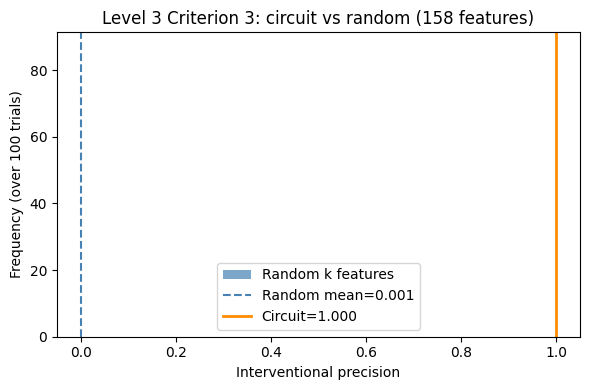

In [12]:
N_TRIALS  = 100
k_circuit = len(circuit_l3)
rng       = np.random.default_rng(seed=0)

random_precisions = []
for _ in tqdm(range(N_TRIALS), desc="Random feature baseline"):
    rand_idx = torch.tensor(
        rng.choice(D_SAE, size=k_circuit, replace=False), dtype=torch.long)
    rand_src = src_feats[:, rand_idx]

    def l3_random_hook(value, hook, ri=rand_idx, rs=rand_src):
        pf = base_feats.clone().to(value.device)
        pf[:, ri] = rs.to(value.device)
        value[:, -1, :] = sae.decode(pf)
        return value

    with torch.no_grad():
        rand_logits = model.run_with_hooks(
            base_x, fwd_hooks=[(MLP_HOOK, l3_random_hook)])[:, -1, :]
    random_precisions.append(interventional_precision(rand_logits, source_y))

rand_mean = float(np.mean(random_precisions))
rand_std  = float(np.std(random_precisions))

print(f"Circuit features (k={k_circuit}):  precision = {precision_l3:.4f}")
print(f"Random  features (k={k_circuit}):  precision = {rand_mean:.4f} ± {rand_std:.4f}  (n={N_TRIALS})")
print(f"Lift over random: {precision_l3 - rand_mean:+.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(random_precisions, bins=20, color="steelblue", alpha=0.7, label="Random k features")
ax.axvline(rand_mean, color="steelblue", linestyle="--", linewidth=1.5, label=f"Random mean={rand_mean:.3f}")
ax.axvline(precision_l3, color="darkorange", linestyle="-", linewidth=2, label=f"Circuit={precision_l3:.3f}")
ax.set_xlabel("Interventional precision")
ax.set_ylabel("Frequency (over 100 trials)")
ax.set_title(f"Level 3 Criterion 3: circuit vs random ({k_circuit} features)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "criterion3_l3_random_baseline.png", dpi=150)
plt.show()

### Interpreting the result

`rand_mean` = 0, `precision_l3` = 1.0 
The circuit correctly isolates the causal computation at the SAE feature level. 

---

## Part 2: IOI task

**Setup**: load GPT-2 Small and build the IOI / pABC datasets, identical to `02bis`, `03bis`, `04bis`.

In [2]:
model_ioi = HookedTransformer.from_pretrained(
    "gpt2",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
)
# use_attn_result is intentionally NOT enabled:
# it materializes [batch, seq, 12, 768] at every attention layer on every forward pass,
# We use hook_z ([batch, seq, 12, 64]) instead,
# and equivalent through W_O (patching z is identical to patching result via linearity).
model_ioi.eval()
model_ioi.to(device)

N_LAYERS_IOI     = model_ioi.cfg.n_layers   # 12
N_HEADS_IOI      = model_ioi.cfg.n_heads    # 12
D_MLP_IOI        = model_ioi.cfg.d_mlp      # 3072
D_HEAD_IOI       = model_ioi.cfg.d_head     # 64
IOI_TARGET_LAYER = 9
D_SAE_IOI        = D_MLP_IOI * 4            # 12288
print(f"GPT-2 Small loaded: {N_LAYERS_IOI}L x {N_HEADS_IOI}H  D_MLP={D_MLP_IOI}  D_head={D_HEAD_IOI}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cpu
GPT-2 Small loaded: 12L x 12H  D_MLP=3072  D_head=64


In [3]:
NAMES_IOI = [
    "Mary", "John", "Alice", "Bob", "Emma", "Frank", "Grace", "Henry",
    "Iris", "Jack", "Kate", "Liam", "Mia", "Noah", "Olivia", "Paul",
    "Rose", "Sam", "Tina", "Victor", "Wendy", "Anna", "Brian", "Clara",
    "Elena", "Felix", "Gina", "Harry", "Jake", "Luna", "Mark", "Nina",
    "Oscar", "Pam", "Ray", "Sara", "Tom", "Vera", "Will", "Zoe"
]
PLACES_IOI  = ["store", "school", "park", "office", "market", "gym",
               "beach", "hotel", "library", "theater", "hospital", "mall"]
OBJECTS_IOI = ["drink", "book", "ball", "bag", "gift", "key",
               "pen", "hat", "ring", "card", "toy", "cup"]
TEMPLATES_IOI = [
    "Then, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] were working at the [PLACE]. [S] decided to give a [OBJECT] to",
    "Then, [IO] and [S] were thinking about going to the [PLACE]. [S] wanted to give a [OBJECT] to",
    "After [IO] and [S] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [IO] and [S] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [IO] and [S] were working at the [PLACE], [S] gave a [OBJECT] to",
    "While [IO] and [S] were commuting to the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [IO] and [S] went to had a [OBJECT]. [S] gave it to",
    "Friends [IO] and [S] found a [OBJECT] at the [PLACE]. [S] gave it to",
    "Then, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [S] and [IO] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "After [S] and [IO] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [S] and [IO] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [S] and [IO] were working at the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [S] and [IO] went to had a [OBJECT]. [S] gave it to",
]

def build_ioi_dataset(N, use_abc=False, seed=42):
    rng = random.Random(seed)
    dataset = []
    for i in range(N):
        template = rng.choice(TEMPLATES_IOI)
        place    = rng.choice(PLACES_IOI)
        obj      = rng.choice(OBJECTS_IOI)
        if use_abc:
            a, b, c = rng.sample(NAMES_IOI, 3)
            prompt = (template.replace("[IO]", a).replace("[S]", b, 1)
                              .replace("[S]", c).replace("[PLACE]", place).replace("[OBJECT]", obj))
            io_name, s_name = a, b
        else:
            io_name, s_name = rng.sample(NAMES_IOI, 2)
            prompt = (template.replace("[IO]", io_name).replace("[S]", s_name)
                              .replace("[PLACE]", place).replace("[OBJECT]", obj))
        dataset.append({"prompt": prompt, "io": io_name, "s": s_name})
    return dataset

def tokenize_ioi(data, model):
    valid = []
    for ex in data:
        io_tok = model.to_tokens(" " + ex["io"], prepend_bos=False).squeeze()
        s_tok  = model.to_tokens(" " + ex["s"],  prepend_bos=False).squeeze()
        if io_tok.ndim == 0 and s_tok.ndim == 0:
            valid.append({**ex, "io_tok": io_tok.item(), "s_tok": s_tok.item()})
    return valid

def batch_ioi_tokens(valid_data, model, device):
    toks = [model.to_tokens(ex["prompt"], prepend_bos=True).squeeze() for ex in valid_data]
    max_len = max(t.shape[0] for t in toks)
    padded = torch.full((len(toks), max_len), 50256, dtype=torch.long)
    for i, t in enumerate(toks):
        padded[i, :t.shape[0]] = t
    return padded.to(device)

N_IOI = 200
ioi_data_eval = build_ioi_dataset(N_IOI, use_abc=False, seed=42)
ioi_valid_eval = tokenize_ioi(ioi_data_eval, model_ioi)
ioi_tokens_eval = batch_ioi_tokens(ioi_valid_eval, model_ioi, device)
ioi_fps_eval = torch.tensor(
    [model_ioi.to_tokens(ex["prompt"], prepend_bos=True).shape[-1] - 1
     for ex in ioi_valid_eval], dtype=torch.long).to(device)

print(f"IOI eval examples: {len(ioi_valid_eval)}")
print(f"Token matrix: {ioi_tokens_eval.shape}  Final pos range: [{ioi_fps_eval.min()}, {ioi_fps_eval.max()}]")
print(f"Example: {ioi_valid_eval[0]['prompt']!r}")
print(f"  IO={ioi_valid_eval[0]['io']}  S={ioi_valid_eval[0]['s']}")

IOI eval examples: 200
Token matrix: torch.Size([200, 21])  Final pos range: [14, 20]
Example: 'Then, Sam and Paul were thinking about going to the store. Paul wanted to give a cup to'
  IO=Sam  S=Paul


### Load IOI circuit definitions

In [4]:
with open(L1_IOI_RESULTS) as f: l1_ioi = json.load(f)
with open(L2_IOI_RESULTS) as f: l2_ioi = json.load(f)
with open(L3_IOI_RESULTS) as f: l3_ioi = json.load(f)

# Level 1: (layer, neuron_idx) pairs
circuit_l1_ioi = [(int(l), j) for l, js in l1_ioi["circuit_by_layer"].items() for j in js]
print(f"L1 IOI circuit: {len(circuit_l1_ioi)} neurons across layers")

# Level 2: (layer, head) pairs
circuit_l2_ioi = [(l, h) for l, h in l2_ioi["circuit_heads"]]
print(f"L2 IOI circuit: {len(circuit_l2_ioi)} heads: {circuit_l2_ioi}")

# Level 3: SAE feature indices
circuit_l3_ioi = l3_ioi["circuit_features"]
print(f"L3 IOI circuit: {len(circuit_l3_ioi)} SAE features at MLP{IOI_TARGET_LAYER}")

L1 IOI circuit: 27 neurons across layers
L2 IOI circuit: 2 heads: [(9, 9), (9, 6)]
L3 IOI circuit: 338 SAE features at MLP9


### Build IOI intervention pairs

For each base example we pick a source example where the IO token differs.
After patching, the model should predict the source IO.

Patching strategy: keep all base activations; replace only circuit components at the
final token position with their source values. this isolates whether
the circuit alone carries sufficient causal information.

In [5]:
N_PAIRS_IOI = len(ioi_valid_eval)  # use all 200 examples
rng_ioi = np.random.default_rng(seed=7)

base_idx_ioi = np.arange(N_PAIRS_IOI)
src_idx_ioi  = rng_ioi.permutation(N_PAIRS_IOI)

# Ensure source IO ≠ base IO for every pair
for i in range(N_PAIRS_IOI):
    attempts = 0
    while ioi_valid_eval[src_idx_ioi[i]]["io_tok"] == ioi_valid_eval[base_idx_ioi[i]]["io_tok"]:
        src_idx_ioi[i] = rng_ioi.integers(0, N_PAIRS_IOI)
        attempts += 1
        if attempts > 1000:
            raise RuntimeError(f"Could not find distinct source IO for base {i}")

base_data_ioi   = [ioi_valid_eval[i] for i in base_idx_ioi]
source_data_ioi = [ioi_valid_eval[i] for i in src_idx_ioi]

base_tokens_ioi   = ioi_tokens_eval[base_idx_ioi]
source_tokens_ioi = ioi_tokens_eval[src_idx_ioi]
base_fps_ioi      = ioi_fps_eval[base_idx_ioi]
source_fps_ioi    = ioi_fps_eval[src_idx_ioi]

# Verify baselines: model should predict base IO with high accuracy unpatched
BATCH_IOI = 16
base_logits_list = []
with torch.no_grad():
    for start in range(0, N_PAIRS_IOI, BATCH_IOI):
        end = min(start + BATCH_IOI, N_PAIRS_IOI)
        base_logits_list.append(model_ioi(base_tokens_ioi[start:end]).cpu())
        torch.cuda.empty_cache()
base_logits_ioi = torch.cat(base_logits_list, dim=0)

def ioi_precision(logits, target_data, fps, device_):
    """Fraction of examples where model predicts the target data's IO token."""
    n = len(target_data)
    correct = 0
    for i, ex in enumerate(target_data):
        pred = logits[i, fps[i].item()].argmax().item()
        correct += int(pred == ex["io_tok"])
    return correct / n

def ioi_chance():
    return 1 / len(NAMES_IOI)   # 1/40 = 0.025

unpatched_base_acc  = ioi_precision(base_logits_ioi, base_data_ioi, base_fps_ioi.cpu(), device)
unpatched_src_acc   = ioi_precision(base_logits_ioi, source_data_ioi, base_fps_ioi.cpu(), device)

print(f"Pairs: {N_PAIRS_IOI}")
print(f"Unpatched accuracy on base IO:   {unpatched_base_acc:.3f}  (should be ~0.99)")
print(f"Unpatched accuracy on source IO: {unpatched_src_acc:.3f}  (should be ~chance={ioi_chance():.3f})")
print(f"Chance level (1/{len(NAMES_IOI)}): {ioi_chance():.3f}")

Pairs: 200
Unpatched accuracy on base IO:   0.940  (should be ~0.99)
Unpatched accuracy on source IO: 0.000  (should be ~chance=0.025)
Chance level (1/40): 0.025


### Cache source activations

Pre-cache source circuit activations for all three levels at final token positions.

In [6]:
# hook_z shape: [batch, seq, n_heads, d_head] 
Z_HOOK_IOI   = lambda l: f"blocks.{l}.attn.hook_z"
MLP_HOOK_IOI = lambda l: f"blocks.{l}.mlp.hook_post"

# Collect every needed hook name: ONE forward pass per batch for all three levels
circuit_l2_layers = sorted(set(l for l, h in circuit_l2_ioi))
circuit_l1_layers = sorted(set(l for l, j in circuit_l1_ioi))

needed_hooks = list(set(
    [Z_HOOK_IOI(l)   for l in circuit_l2_layers] +
    [MLP_HOOK_IOI(l) for l in circuit_l1_layers] +
    [MLP_HOOK_IOI(IOI_TARGET_LAYER)]
))
print(f"Single-pass caching {len(needed_hooks)} hooks: {sorted(needed_hooks)}")

# Initialise storage
# src_z_acts_ioi[(l, h)]: [N_PAIRS, d_head=64]
src_z_acts_ioi   = {(l, h): [] for l, h in circuit_l2_ioi}
src_mlp_acts_ioi = {l: []      for l in circuit_l1_layers}
src_mlp3_ioi_list = []

BATCH_CACHE = 8
source_tokens_cpu = source_tokens_ioi.cpu()
source_fps_cpu    = source_fps_ioi.cpu()

with torch.no_grad():
    for start in tqdm(range(0, N_PAIRS_IOI, BATCH_CACHE), desc="Caching source acts"):
        end    = min(start + BATCH_CACHE, N_PAIRS_IOI)
        fps_s  = source_fps_cpu[start:end].to(device)
        tokens = source_tokens_cpu[start:end].to(device)
        bs     = end - start
        bi     = torch.arange(bs, device=device)

        _, cache = model_ioi.run_with_cache(tokens, names_filter=needed_hooks)

        # L2 per-head z values at source final positions, shape [bs, d_head]
        for l in circuit_l2_layers:
            acts = cache[Z_HOOK_IOI(l)]        # [bs, seq, n_heads, d_head]
            for ll, h in circuit_l2_ioi:
                if ll == l:
                    src_z_acts_ioi[(l, h)].append(acts[bi, fps_s, h].cpu())

        # L1 neuron activations
        for l in circuit_l1_layers:
            acts = cache[MLP_HOOK_IOI(l)]      # [bs, seq, d_mlp]
            src_mlp_acts_ioi[l].append(acts[bi, fps_s].cpu())

        # L3 MLP3 activations
        acts3 = cache[MLP_HOOK_IOI(IOI_TARGET_LAYER)]
        src_mlp3_ioi_list.append(acts3[bi, fps_s].cpu())

        del cache, acts3, tokens
        torch.cuda.empty_cache()

for k in src_z_acts_ioi:
    src_z_acts_ioi[k]    = torch.cat(src_z_acts_ioi[k],    dim=0)  # [N_PAIRS, d_head]
for l in src_mlp_acts_ioi:
    src_mlp_acts_ioi[l]  = torch.cat(src_mlp_acts_ioi[l],  dim=0)  # [N_PAIRS, d_mlp]
src_mlp3_ioi = torch.cat(src_mlp3_ioi_list, dim=0)                  # [N_PAIRS, d_mlp]

print(f"L2 z acts: {list(src_z_acts_ioi.keys())}  shape={list(src_z_acts_ioi.values())[0].shape}")
print(f"L1 MLP acts cached for layers: {list(src_mlp_acts_ioi.keys())}")
print(f"L3 MLP3 source acts: {src_mlp3_ioi.shape}")

Single-pass caching 12 hooks: ['blocks.0.mlp.hook_post', 'blocks.10.mlp.hook_post', 'blocks.11.mlp.hook_post', 'blocks.2.mlp.hook_post', 'blocks.3.mlp.hook_post', 'blocks.4.mlp.hook_post', 'blocks.5.mlp.hook_post', 'blocks.6.mlp.hook_post', 'blocks.7.mlp.hook_post', 'blocks.8.mlp.hook_post', 'blocks.9.attn.hook_z', 'blocks.9.mlp.hook_post']


Caching source acts:   0%|          | 0/25 [00:00<?, ?it/s]

L2 z acts: [(9, 9), (9, 6)]  shape=torch.Size([200, 64])
L1 MLP acts cached for layers: [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
L3 MLP3 source acts: torch.Size([200, 3072])


### IOI Level 2 Attention heads interventional precision

Circuit: L9H9, L9H6 (name-mover heads). These carry the IO token's identity from
its first-mention position to the final token via the direct effect mechanism.
After patching their outputs from the source run into the base run, the model should
output the source IO name.

In [9]:
circuit_l2_by_layer_ioi = {}
for l, h in circuit_l2_ioi:
    circuit_l2_by_layer_ioi.setdefault(l, []).append(h)

def make_l2_patch_hooks_ioi(batch_start, batch_fps):
    hooks = []
    bs = len(batch_fps)
    for l, heads in circuit_l2_by_layer_ioi.items():
        src_z_batch = {
            h: src_z_acts_ioi[(l, h)][batch_start:batch_start + bs].to(device)
            for h in heads
        }
        def make_hook(fp=batch_fps, sz=src_z_batch, hs=heads):
            def hook_fn(value, hook):
                bi = torch.arange(value.shape[0], device=value.device)
                for h in hs:
                    value[bi, fp, h] = sz[h]
                return value
            return hook_fn
        hooks.append((Z_HOOK_IOI(l), make_hook()))
    return hooks

BATCH_PATCH = 4
base_tokens_cpu = base_tokens_ioi.cpu()
base_fps_cpu    = base_fps_ioi.cpu()

# Compute on-the-fly: never accumulate [batch, seq, vocab] logits.
correct_l2 = 0
with torch.no_grad():
    for start in tqdm(range(0, N_PAIRS_IOI, BATCH_PATCH), desc="IOI L2 patching"):
        end       = min(start + BATCH_PATCH, N_PAIRS_IOI)
        batch_fps = base_fps_cpu[start:end].to(device)
        tokens    = base_tokens_cpu[start:end].to(device)
        logits    = model_ioi.run_with_hooks(
            tokens, fwd_hooks=make_l2_patch_hooks_ioi(start, batch_fps))
        for i in range(end - start):
            pred = logits[i, batch_fps[i].item()].argmax().item()
            correct_l2 += int(pred == source_data_ioi[start + i]["io_tok"])
        del logits, tokens
        torch.cuda.empty_cache()

precision_l2_ioi = correct_l2 / N_PAIRS_IOI
print(f"IOI Level 2 interventional precision (circuit heads, hook_z): {precision_l2_ioi:.4f}")
print(f"(Chance: {ioi_chance():.3f}  |  N={N_PAIRS_IOI})")

IOI L2 patching:   0%|          | 0/50 [00:00<?, ?it/s]

IOI Level 2 interventional precision (circuit heads, hook_z): 0.1550
(Chance: 0.025  |  N=200)


### IOI Level 1 MLP neurons interventional precision

Circuit: 27 neurons across 12 MLP layers (from greedy search in `02bis`).
These neurons together achieve RS = 0.91 on faithfulness despite individual RS < 0.08.
We expect lower interventional precision than Level 2: MLP neurons contribute indirectly,
so swapping only their outputs may not reliably flip the output to the source IO.

In [11]:
circuit_l1_by_layer_ioi = {}
for l, j in circuit_l1_ioi:
    circuit_l1_by_layer_ioi.setdefault(l, []).append(j)

def make_l1_patch_hooks_ioi(batch_start, batch_fps):
    hooks = []
    bs = len(batch_fps)
    for l, neurons in circuit_l1_by_layer_ioi.items():
        ct = torch.tensor(neurons, dtype=torch.long)
        sa = src_mlp_acts_ioi[l][batch_start:batch_start + bs].to(device)
        def make_hook(fp=batch_fps, ct_=ct, sa_=sa):
            def hook_fn(value, hook):
                bi = torch.arange(value.shape[0], device=value.device)
                value[bi[:, None], fp[:, None], ct_.to(value.device)] = sa_[:, ct_]
                return value
            return hook_fn
        hooks.append((MLP_HOOK_IOI(l), make_hook()))
    return hooks

correct_l1 = 0
with torch.no_grad():
    for start in tqdm(range(0, N_PAIRS_IOI, BATCH_PATCH), desc="IOI L1 patching"):
        end       = min(start + BATCH_PATCH, N_PAIRS_IOI)
        batch_fps = base_fps_cpu[start:end].to(device)
        tokens    = base_tokens_cpu[start:end].to(device)
        logits    = model_ioi.run_with_hooks(
            tokens, fwd_hooks=make_l1_patch_hooks_ioi(start, batch_fps))
        for i in range(end - start):
            pred = logits[i, batch_fps[i].item()].argmax().item()
            correct_l1 += int(pred == source_data_ioi[start + i]["io_tok"])
        del logits, tokens
        torch.cuda.empty_cache()

precision_l1_ioi = correct_l1 / N_PAIRS_IOI
print(f"IOI Level 1 interventional precision (neurons): {precision_l1_ioi:.4f}")
print(f"(Chance: {ioi_chance():.3f}  |  N={N_PAIRS_IOI})")

IOI L1 patching:   0%|          | 0/50 [00:00<?, ?it/s]

IOI Level 1 interventional precision (neurons): 0.0000
(Chance: 0.025  |  N=200)


the next two cells are sanity checks to see if the 0.0 interventional precision result is correct

In [12]:
# Diagnostic: inspect circuit_l1_ioi provenance and validity
print(f"circuit_l1_ioi: {len(circuit_l1_ioi)} (l, j) pairs")
print(f"circuit_l1_by_layer_ioi: {circuit_l1_by_layer_ioi}")
print()

# Non-empty?
assert len(circuit_l1_ioi) > 0, "circuit_l1_ioi is EMPTY — no hooks fire, patch is inert"

# j indices in valid hook_post range [0, d_mlp)?
d_mlp = model_ioi.cfg.d_mlp
all_j = [j for l, j in circuit_l1_ioi]
print(f"d_mlp (hook_post width): {d_mlp}")
print(f"j range: min={min(all_j)}, max={max(all_j)}")
oob = [(l, j) for l, j in circuit_l1_ioi if not (0 <= j < d_mlp)]
if oob:
    print(f"OUT OF RANGE for hook_post: {oob}")
    print("  -> j was likely selected against a different space "
          "(hook_pre is also d_mlp; residual/mlp_out is d_model=768)")
else:
    print(f"All j in [0, {d_mlp}) — consistent with a hook_post-width selection")
print()

# Layers actually present, and do they map to real MLP hooks?
print(f"layers in circuit: {sorted(circuit_l1_by_layer_ioi.keys())}")
print(f"n_layers: {model_ioi.cfg.n_layers}")
for l in sorted(circuit_l1_by_layer_ioi):
    assert 0 <= l < model_ioi.cfg.n_layers, f"layer {l} out of range"
    print(f"  layer {l}: {len(circuit_l1_by_layer_ioi[l])} neurons, hook = {MLP_HOOK_IOI(l)}")

circuit_l1_ioi: 27 (l, j) pairs
circuit_l1_by_layer_ioi: {0: [179, 92], 2: [281], 3: [1874, 92], 4: [202, 1847], 5: [1405, 1577, 793], 6: [2314, 2864, 628, 3057, 2038, 1645], 7: [1871, 180, 2794, 498], 8: [1253, 1548], 9: [370], 10: [1999, 928], 11: [2926, 3029]}

d_mlp (hook_post width): 3072
j range: min=92, max=3057
All j in [0, 3072) — consistent with a hook_post-width selection

layers in circuit: [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
n_layers: 12
  layer 0: 2 neurons, hook = blocks.0.mlp.hook_post
  layer 2: 1 neurons, hook = blocks.2.mlp.hook_post
  layer 3: 2 neurons, hook = blocks.3.mlp.hook_post
  layer 4: 2 neurons, hook = blocks.4.mlp.hook_post
  layer 5: 3 neurons, hook = blocks.5.mlp.hook_post
  layer 6: 6 neurons, hook = blocks.6.mlp.hook_post
  layer 7: 4 neurons, hook = blocks.7.mlp.hook_post
  layer 8: 2 neurons, hook = blocks.8.mlp.hook_post
  layer 9: 1 neurons, hook = blocks.9.mlp.hook_post
  layer 10: 2 neurons, hook = blocks.10.mlp.hook_post
  layer 11: 2 neurons, 

In [13]:
# Re-run L1 patch, this time scoring against BOTH base IO and source IO
correct_l1_src  = 0
correct_l1_base = 0
with torch.no_grad():
    for start in tqdm(range(0, N_PAIRS_IOI, BATCH_PATCH), desc="IOI L1 patch (fork)"):
        end       = min(start + BATCH_PATCH, N_PAIRS_IOI)
        batch_fps = base_fps_cpu[start:end].to(device)
        tokens    = base_tokens_cpu[start:end].to(device)
        logits    = model_ioi.run_with_hooks(
            tokens, fwd_hooks=make_l1_patch_hooks_ioi(start, batch_fps))
        for i in range(end - start):
            pred = logits[i, batch_fps[i].item()].argmax().item()
            correct_l1_src  += int(pred == source_data_ioi[start + i]["io_tok"])
            correct_l1_base += int(pred == base_data_ioi[start + i]["io_tok"])
        del logits, tokens
        torch.cuda.empty_cache()

print(f"patched -> source IO: {correct_l1_src  / N_PAIRS_IOI:.4f}  (this is precision_l1_ioi)")
print(f"patched -> base IO:   {correct_l1_base / N_PAIRS_IOI:.4f}")
print(f"unpatched base was ~0.99; chance ~{ioi_chance():.3f}")

IOI L1 patch (fork):   0%|          | 0/50 [00:00<?, ?it/s]

patched -> source IO: 0.0000  (this is precision_l1_ioi)
patched -> base IO:   0.9250
unpatched base was ~0.99; chance ~0.025


### IOI Level 3 SAE features interventional precision

Circuit: 96 SAE features at MLP3. The SAE was trained on MLP3 post-GELU activations.
We patch the 96 circuit features from source into base, keeping all other features at base
values, and decode back to MLP3 activation space.

Same random baseline as the grokking L3 analysis: if k random features give the same
precision as circuit features, the circuit is not causally specific.

In [7]:
# Load the IOI SAE (same architecture as 04bis_level3_sae(IOI).ipynb)
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in, d_sae, l1_coeff=2e-4):
        super().__init__()
        self.d_in = d_in; self.d_sae = d_sae; self.l1_coeff = l1_coeff
        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))
        nn.init.kaiming_uniform_(self.W_enc); nn.init.kaiming_uniform_(self.W_dec)
    def encode(self, x):
        return torch.relu((x - self.b_dec) @ self.W_enc + self.b_enc)
    def decode(self, f):
        return f @ self.W_dec + self.b_dec

sae_ioi = SparseAutoencoder(d_in=D_MLP_IOI, d_sae=D_SAE_IOI).to(device)
sae_ioi.load_state_dict(torch.load(SAE_IOI_PATH, map_location=device))
sae_ioi.eval()
print(f"IOI SAE loaded: {D_MLP_IOI} -> {D_SAE_IOI} -> {D_MLP_IOI}")

# Cache base MLP3 activations and encode through SAE
base_mlp3_ioi = []
with torch.no_grad():
    for start in range(0, N_PAIRS_IOI, BATCH_IOI):
        end      = min(start + BATCH_IOI, N_PAIRS_IOI)
        fps_b    = base_fps_ioi[start:end]
        hook_name = MLP_HOOK_IOI(IOI_TARGET_LAYER)
        _, cache = model_ioi.run_with_cache(base_tokens_ioi[start:end], names_filter=hook_name)
        acts = cache[hook_name]
        bi   = torch.arange(acts.shape[0], device=device)
        base_mlp3_ioi.append(acts[bi, fps_b].cpu())
        del cache; torch.cuda.empty_cache()

base_mlp3_ioi = torch.cat(base_mlp3_ioi, dim=0)   # [N_PAIRS, D_MLP_IOI]

with torch.no_grad():
    base_feats_ioi = sae_ioi.encode(base_mlp3_ioi.to(device)).cpu()   # [N_PAIRS, D_SAE_IOI]
    src_feats_ioi  = sae_ioi.encode(src_mlp3_ioi.to(device)).cpu()    # [N_PAIRS, D_SAE_IOI]

circuit_l3_t_ioi = torch.tensor(circuit_l3_ioi, dtype=torch.long)
print(f"Base feats: {base_feats_ioi.shape}  Source feats: {src_feats_ioi.shape}")
print(f"Circuit features: {len(circuit_l3_ioi)}")

IOI SAE loaded: 3072 -> 12288 -> 3072
Base feats: torch.Size([200, 12288])  Source feats: torch.Size([200, 12288])
Circuit features: 338


IOI Level 3 interventional precision (SAE circuit features): 0.0000


IOI L3 random baseline:   0%|          | 0/20 [00:00<?, ?it/s]

Circuit features (k=338): precision = 0.0000
Random  features (k=338): precision = 0.0000 ± 0.0000  (n=20)
Lift over random: +0.0000


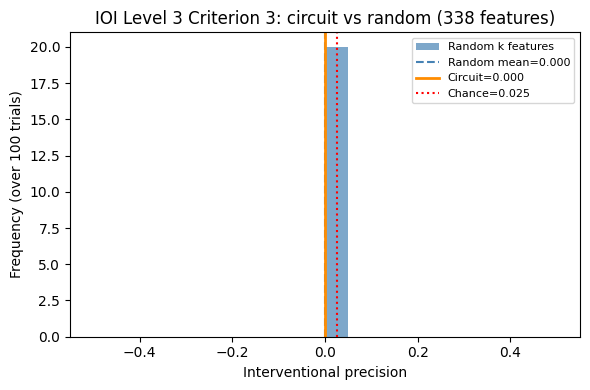

In [10]:
hook_name_l3_ioi = MLP_HOOK_IOI(IOI_TARGET_LAYER)

def run_l3_ioi_patching(circuit_feat_idx):
    """Run one round of L3 patching and return precision. Never stores full logits."""
    correct = 0
    with torch.no_grad():
        for start in range(0, N_PAIRS_IOI, BATCH_PATCH):
            end   = min(start + BATCH_PATCH, N_PAIRS_IOI)
            fps_b = base_fps_cpu[start:end].to(device)
            toks  = base_tokens_cpu[start:end].to(device)
            bf    = base_feats_ioi[start:end].clone()
            bf[:, circuit_feat_idx] = src_feats_ioi[start:end, circuit_feat_idx]

            def hook_fn(value, hook, fp=fps_b, pf=bf):
                bi = torch.arange(value.shape[0], device=value.device)
                value[bi, fp] = sae_ioi.decode(pf.to(value.device))
                return value

            logits = model_ioi.run_with_hooks(toks, fwd_hooks=[(hook_name_l3_ioi, hook_fn)])
            for i in range(end - start):
                pred = logits[i, fps_b[i].item()].argmax().item()
                correct += int(pred == source_data_ioi[start + i]["io_tok"])
            del logits, toks
            torch.cuda.empty_cache()
    return correct / N_PAIRS_IOI

precision_l3_ioi = run_l3_ioi_patching(circuit_l3_t_ioi)
print(f"IOI Level 3 interventional precision (SAE circuit features): {precision_l3_ioi:.4f}")

# Random baseline
N_TRIALS_IOI = 20  # L3 IOI precision is 0; 20 trials confirms random baseline is also 0
k_ioi        = len(circuit_l3_ioi)
rng_rand_ioi = np.random.default_rng(seed=1)
rand_prec_ioi = []

for _ in tqdm(range(N_TRIALS_IOI), desc="IOI L3 random baseline"):
    rand_idx = torch.tensor(rng_rand_ioi.choice(D_SAE_IOI, size=k_ioi, replace=False), dtype=torch.long)
    rand_prec_ioi.append(run_l3_ioi_patching(rand_idx))

rand_mean_ioi = float(np.mean(rand_prec_ioi))
rand_std_ioi  = float(np.std(rand_prec_ioi))
lift_ioi      = precision_l3_ioi - rand_mean_ioi

print(f"Circuit features (k={k_ioi}): precision = {precision_l3_ioi:.4f}")
print(f"Random  features (k={k_ioi}): precision = {rand_mean_ioi:.4f} ± {rand_std_ioi:.4f}  (n={N_TRIALS_IOI})")
print(f"Lift over random: {lift_ioi:+.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rand_prec_ioi, bins=20, color="steelblue", alpha=0.7, label="Random k features")
ax.axvline(rand_mean_ioi, color="steelblue", linestyle="--", linewidth=1.5, label=f"Random mean={rand_mean_ioi:.3f}")
ax.axvline(precision_l3_ioi, color="darkorange", linewidth=2, label=f"Circuit={precision_l3_ioi:.3f}")
ax.axvline(ioi_chance(), color="red", linestyle=":", linewidth=1.5, label=f"Chance={ioi_chance():.3f}")
ax.set_xlabel("Interventional precision"); ax.set_ylabel("Frequency (over 100 trials)")
ax.set_title(f"IOI Level 3 Criterion 3: circuit vs random ({k_ioi} features)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "criterion3_ioi_l3_random_baseline.png", dpi=150)
plt.show()

In [22]:
print("=" * 80)
print("  GROKKING TASK Three-criterion evaluation (modular arithmetic mod 113)")
print("=" * 80)
print(f"{'':25s}  {'Level 1':>10s}  {'Level 2':>10s}  {'Level 3':>10s}")
print(f"{'':25s}  {'neurons':>10s}  {'heads/MLP':>10s}  {'SAE feats':>10s}")
print("=" * 80)
print(f"{'Criterion 1 Faithfulness':25s}  "
      f"{l1['criterion1_faithfulness']:>10.4f}  "
      f"{l2['criterion1_faithfulness']:>10.4f}  "
      f"{l3['criterion1_faithfulness']:>10.4f}")
print(f"{'Criterion 2 DL':25s}  "
      f"{l1['criterion2_description_length']:>10.4f}  "
      f"{l2['criterion2_description_length']:>10.4f}  "
      f"{l3['criterion2_description_length']:>10.4f}")
print(f"{'Criterion 3 C3 precision':25s}  "
      f"{precision_l1:>10.4f}  "
      f"{precision_l2:>10.4f}  "
      f"{precision_l3:>10.4f}")
print(f"{'  L3 random baseline':25s}  "
      f"{'—':>10s}  {'—':>10s}  "
      f"{rand_mean:>8.4f}±{rand_std:.3f}")
print(f"{'  Chance (1/{P})':25s}  "
      f"{chance_precision():>10.4f}  "
      f"{chance_precision():>10.4f}  "
      f"{chance_precision():>10.4f}")
print()

print("=" * 80)
print("  IOI TASK Three-criterion evaluation (GPT-2 Small, N=200)")
print("=" * 80)
print(f"{'':25s}  {'Level 1':>10s}  {'Level 2':>10s}  {'Level 3':>10s}")
print(f"{'':25s}  {'neurons':>10s}  {'att. heads':>10s}  {'SAE feats':>10s}")
print("=" * 80)
print(f"{'Criterion 1 Faithfulness':25s}  "
      f"{l1_ioi['criterion1_faithfulness']:>10.4f}  "
      f"{l2_ioi['criterion1_faithfulness']:>10.4f}  "
      f"{l3_ioi['criterion1_faithfulness']:>10.4f}")
print(f"{'Criterion 2 DL':25s}  "
      f"{l1_ioi['criterion2_description_length']:>10.4f}  "
      f"{l2_ioi['criterion2_description_length']:>10.4f}  "
      f"{l3_ioi['criterion2_description_length']:>10.4f}")
print(f"{'  circuit / total':25s}  "
      f"{l1_ioi['criterion2_circuit_neurons']:>5d}/{l1_ioi['criterion2_total_neurons']:<6d}  "
      f"{l2_ioi['criterion2_circuit_heads']:>5d}/{l2_ioi['criterion2_total_heads']:<6d}  "
      f"{l3_ioi['criterion2_circuit_features']:>5d}/{l3_ioi['criterion2_total_features']:<6d}")
print(f"{'Criterion 3 C3 precision':25s}  "
      f"{precision_l1_ioi:>10.4f}  "
      f"{precision_l2_ioi:>10.4f}  "
      f"{precision_l3_ioi:>10.4f}")
print(f"{'  L3 random baseline':25s}  "
      f"{'—':>10s}  {'—':>10s}  "
      f"{rand_mean_ioi:>8.4f}±{rand_std_ioi:.3f}")
print(f"{'  Chance (1/40)':25s}  "
      f"{ioi_chance():>10.4f}  "
      f"{ioi_chance():>10.4f}  "
      f"{ioi_chance():>10.4f}")
print()

lift_ioi = precision_l3_ioi - rand_mean_ioi
if lift_ioi < 0.05:
    verdict_ioi = "ARTIFACT circuit precision  random; driven by SAE reconstruction bulk"
elif lift_ioi < 0.20:
    verdict_ioi = "WEAK SIGNAL modest lift over random"
else:
    verdict_ioi = "SIGNAL circuit meaningfully outperforms random features"
print(f"IOI Level 3 Criterion 3 verdict: {verdict_ioi}")

  GROKKING TASK Three-criterion evaluation (modular arithmetic mod 113)
                              Level 1     Level 2     Level 3
                              neurons   heads/MLP   SAE feats
Criterion 1 Faithfulness       1.0000      0.8541      0.9006
Criterion 2 DL                 1.0000      0.6667      0.0771
Criterion 3 C3 precision       0.9950      0.6550      1.0000
  L3 random baseline                —           —    0.0007±0.002
  Chance (1/{P})               0.0088      0.0088      0.0088

  IOI TASK Three-criterion evaluation (GPT-2 Small, N=200)
                              Level 1     Level 2     Level 3
                              neurons  att. heads   SAE feats
Criterion 1 Faithfulness       0.9106      1.2716      0.9012
Criterion 2 DL                 0.0007      0.0139      0.0078
  circuit / total             27/36864       2/144        96/12288 
Criterion 3 C3 precision       0.0000      0.1550      0.0000
  L3 random baseline                —           —   

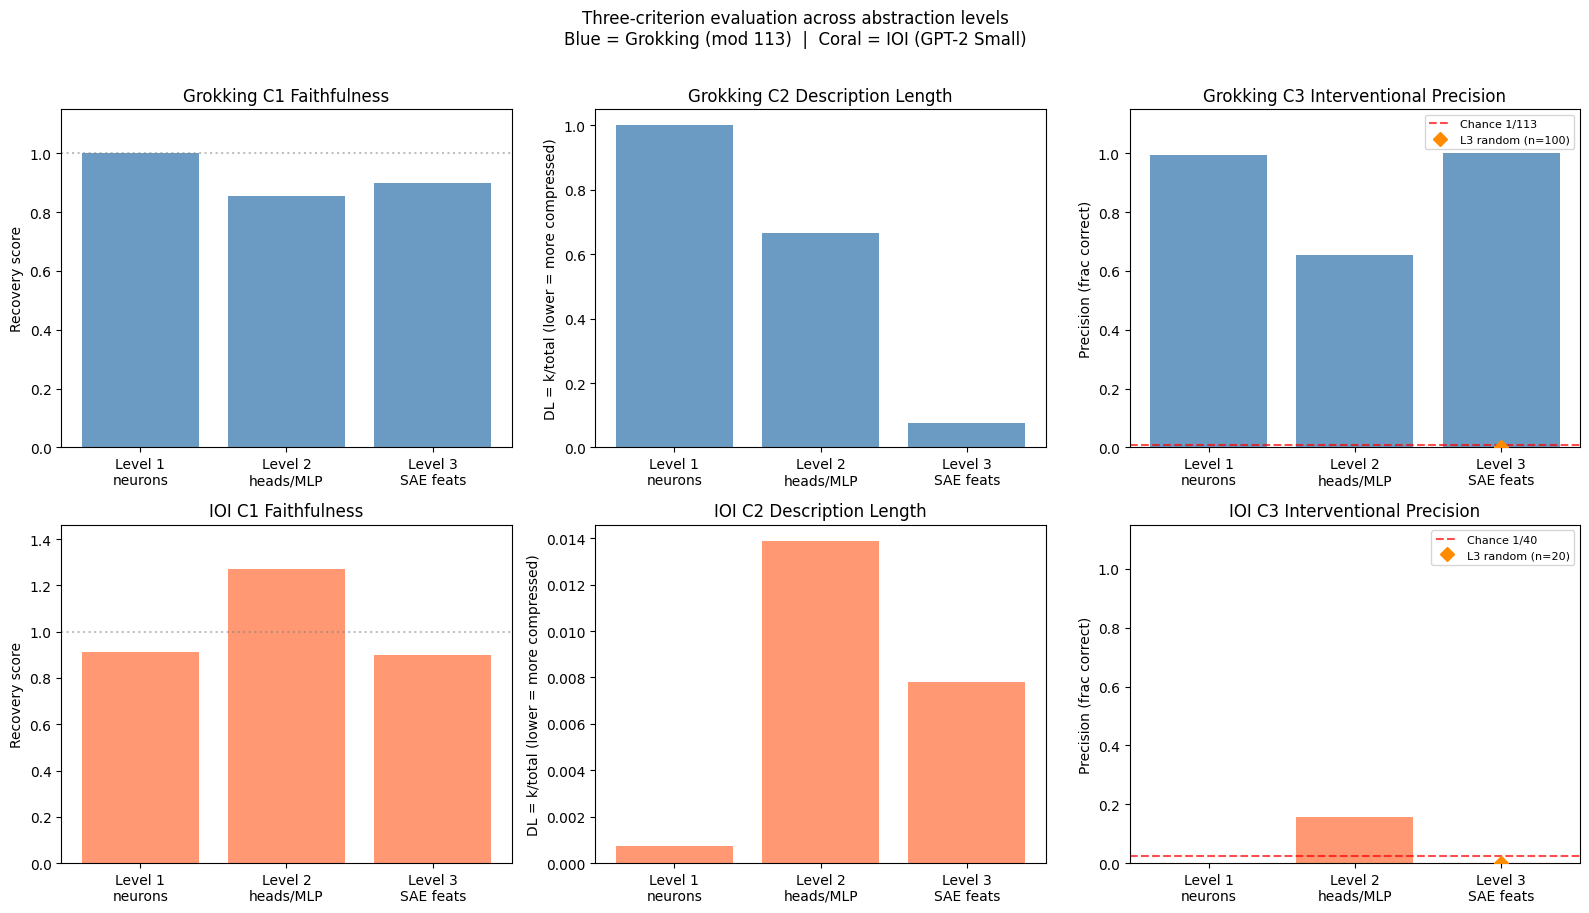

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

levels_labels = ["Level 1\nneurons", "Level 2\nheads/MLP", "Level 3\nSAE feats"]

# ---------- GROKKING (row 0) ----------
chance_grok = chance_precision()

vals1g = [l1['criterion1_faithfulness'], l2['criterion1_faithfulness'], l3['criterion1_faithfulness']]
axes[0, 0].bar(levels_labels, vals1g, color="steelblue", alpha=0.8)
axes[0, 0].axhline(1.0, color="gray", linestyle=":", alpha=0.5)
axes[0, 0].set_ylim(0, 1.15); axes[0, 0].set_ylabel("Recovery score")
axes[0, 0].set_title("Grokking C1 Faithfulness")

vals2g = [l1['criterion2_description_length'], l2['criterion2_description_length'], l3['criterion2_description_length']]
axes[0, 1].bar(levels_labels, vals2g, color="steelblue", alpha=0.8)
axes[0, 1].set_ylabel("DL = k/total (lower = more compressed)")
axes[0, 1].set_title("Grokking C2 Description Length")

vals3g = [precision_l1, precision_l2, precision_l3]
axes[0, 2].bar(levels_labels, vals3g, color="steelblue", alpha=0.8)
axes[0, 2].errorbar([2], [rand_mean], yerr=[rand_std], fmt="D", color="darkorange",
                    markersize=7, linewidth=2, label=f"L3 random (n={N_TRIALS})", zorder=5)
axes[0, 2].fill_between([1.6, 2.4], rand_mean - rand_std, rand_mean + rand_std,
                        color="darkorange", alpha=0.15)
axes[0, 2].axhline(chance_grok, color="red", linestyle="--", label=f"Chance 1/{P}", alpha=0.7)
axes[0, 2].set_ylim(0, 1.15); axes[0, 2].set_ylabel("Precision (frac correct)")
axes[0, 2].set_title("Grokking C3 Interventional Precision")
axes[0, 2].legend(fontsize=8)

# ---------- IOI (row 1) ----------
chance_ioi_val = ioi_chance()

vals1i = [l1_ioi['criterion1_faithfulness'], l2_ioi['criterion1_faithfulness'], l3_ioi['criterion1_faithfulness']]
axes[1, 0].bar(levels_labels, vals1i, color="coral", alpha=0.8)
axes[1, 0].axhline(1.0, color="gray", linestyle=":", alpha=0.5)
axes[1, 0].set_ylim(0, max(vals1i) * 1.15); axes[1, 0].set_ylabel("Recovery score")
axes[1, 0].set_title("IOI C1 Faithfulness")

vals2i = [l1_ioi['criterion2_description_length'], l2_ioi['criterion2_description_length'],
          l3_ioi['criterion2_description_length']]
axes[1, 1].bar(levels_labels, vals2i, color="coral", alpha=0.8)
axes[1, 1].set_ylabel("DL = k/total (lower = more compressed)")
axes[1, 1].set_title("IOI C2 Description Length")

vals3i = [precision_l1_ioi, precision_l2_ioi, precision_l3_ioi]
axes[1, 2].bar(levels_labels, vals3i, color="coral", alpha=0.8)
axes[1, 2].errorbar([2], [rand_mean_ioi], yerr=[rand_std_ioi], fmt="D", color="darkorange",
                    markersize=7, linewidth=2, label=f"L3 random (n={N_TRIALS_IOI})", zorder=5)
axes[1, 2].fill_between([1.6, 2.4], rand_mean_ioi - rand_std_ioi, rand_mean_ioi + rand_std_ioi,
                        color="darkorange", alpha=0.15)
axes[1, 2].axhline(chance_ioi_val, color="red", linestyle="--", label="Chance 1/40", alpha=0.7)
axes[1, 2].set_ylim(0, 1.15); axes[1, 2].set_ylabel("Precision (frac correct)")
axes[1, 2].set_title("IOI C3 Interventional Precision")
axes[1, 2].legend(fontsize=8)

plt.suptitle("Three-criterion evaluation across abstraction levels\n"
             "Blue = Grokking (mod 113)  |  Coral = IOI (GPT-2 Small)", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "three_criteria_summary_both_tasks.png", dpi=150, bbox_inches="tight")
plt.show()

Save Results

In [24]:
results = {
    "grokking": {
        "task": "modular_arithmetic_mod113",
        "n_pairs": N_PAIRS,
        "chance_precision": chance_precision(),
        "unpatched_base_accuracy": base_pred_base,
        "unpatched_source_accuracy": base_pred_source,
        "criterion3": {
            "level1_precision": precision_l1,
            "level2_precision": precision_l2,
            "level3_precision": precision_l3,
            "level3_random_baseline": {
                "n_trials": N_TRIALS,
                "k_features": k_circuit,
                "mean": rand_mean,
                "std": rand_std,
                "all_precisions": random_precisions,
            },
            "level3_lift_over_random": precision_l3 - rand_mean,
            "level3_verdict": (
                "artifact" if (precision_l3 - rand_mean) < 0.05 else
                "weak_signal" if (precision_l3 - rand_mean) < 0.20 else
                "signal"
            ),
        },
    },
    "ioi": {
        "task": "indirect_object_identification",
        "model": "gpt2",
        "n_pairs": N_PAIRS_IOI,
        "chance_precision": ioi_chance(),
        "unpatched_base_accuracy": unpatched_base_acc,
        "unpatched_source_accuracy": unpatched_src_acc,
        "criterion3": {
            "level1_precision": precision_l1_ioi,
            "level1_circuit_neurons": len(circuit_l1_ioi),
            "level2_precision": precision_l2_ioi,
            "level2_circuit_heads": circuit_l2_ioi,
            "level3_precision": precision_l3_ioi,
            "level3_random_baseline": {
                "n_trials": N_TRIALS_IOI,
                "k_features": k_ioi,
                "mean": rand_mean_ioi,
                "std": rand_std_ioi,
                "all_precisions": rand_prec_ioi,
            },
            "level3_lift_over_random": lift_ioi,
            "level3_verdict": verdict_ioi,
        },
    },
}

with open(OUT_DIR / "criterion3_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved to {OUT_DIR}/criterion3_results.json")
print()
print("Summary:")
print(f"  Grokking L1/L2/L3 precision: {precision_l1:.4f} / {precision_l2:.4f} / {precision_l3:.4f}")
print(f"  IOI     L1/L2/L3 precision: {precision_l1_ioi:.4f} / {precision_l2_ioi:.4f} / {precision_l3_ioi:.4f}")

Saved to ..\results\criteria/criterion3_results.json

Summary:
  Grokking L1/L2/L3 precision: 0.9950 / 0.6550 / 1.0000
  IOI     L1/L2/L3 precision: 0.0000 / 0.1550 / 0.0000
